<a href="https://colab.research.google.com/github/Lucasbpofc/Lucasbpofc.github.io/blob/main/Elnino_sul_mg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Instalação das bibliotecas necessárias
!pip install netcdf4 xarray pymannkendall statsmodels geobr joblib -q

# 2. Importações de praxe
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geobr
import geopandas as gpd
from shapely.geometry import Point
from scipy.optimize import minimize
from scipy.stats import genextreme
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings('ignore')

# 3. Processamento do Índice ONI
print("Buscando e processando o índice ONI da NOAA...")
url_oni = "https://psl.noaa.gov/data/correlation/oni.data"
df_oni_bruto = pd.read_csv(url_oni, sep=r'\s+', skiprows=1, skipfooter=8, header=None, engine='python')
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
df_oni_bruto.columns = ['ano'] + meses
df_oni_bruto = df_oni_bruto.replace(-99.90, np.nan)

# Desloca o mês de Dezembro para casar com o Verão do ano seguinte
df_oni_bruto['Dez_anterior'] = df_oni_bruto['Dez'].shift(1)
df_oni_bruto['ONI_Verao'] = df_oni_bruto[['Dez_anterior', 'Jan', 'Fev']].mean(axis=1)

df_covariavel_enso = df_oni_bruto[['ano', 'ONI_Verao']].dropna().copy()
df_covariavel_enso['ano'] = df_covariavel_enso['ano'].astype(int)
print("✅ Índice ONI de Verão pronto!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.2 MB/s eta 0:00:00
Buscando e processando o índice ONI da NOAA...
✅ Índice ONI de Verão pronto!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 1. Carrega as fronteiras oficiais e isola o Sul de Minas
print("Buscando limites espaciais do Sul/Sudoeste de Minas...")
meso_mg = geobr.read_meso_region(code_meso="MG", year=2020)
sul_mg = meso_mg[meso_mg['name_meso'] == 'Sul/Sudoeste de Minas']

# Extrai a "caixa" de coordenadas extremas (min_lon, min_lat, max_lon, max_lat)
min_lon, min_lat, max_lon, max_lat = sul_mg.total_bounds

# 2. Carrega o cubo de dados e já recorta na mosca
caminho_input = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/br_maximas_anuais_oni_1961_2025.nc"
print(f"Lendo e recortando o NetCDF na região alvo...")

ds_br = xr.open_dataset(caminho_input)
ds_ordenado = ds_br.sortby(['latitude', 'longitude'])

# Recorte espacial inteligente usando os limites do Sul de MG (com uma folguinha de 0.2 graus)
ds_sul_mg = ds_ordenado.sel(
    longitude=slice(min_lon - 0.2, max_lon + 0.2),
    latitude=slice(min_lat - 0.2, max_lat + 0.2)
)

print(f"✅ Malha do Sul de MG extraída: {len(ds_sul_mg.latitude)} latitudes x {len(ds_sul_mg.longitude)} longitudes.")

Buscando limites espaciais do Sul/Sudoeste de Minas...
Lendo e recortando o NetCDF na região alvo...
✅ Malha do Sul de MG extraída: 31 latitudes x 37 longitudes.


In [5]:
def ajustar_gev_4_modelos(series_chuva, series_oni):
    validos = ~np.isnan(series_chuva) & ~np.isnan(series_oni)
    y = series_chuva[validos]
    x = series_oni[validos]
    if len(y) < 30: return [np.nan] * 9

    resultados_aic, parametros = {}, {}

    # M0: Estacionário
    def nll_m0(p):
        if p[1] <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -p[2], loc=p[0], scale=p[1]))
    res0 = minimize(nll_m0, [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')
    if res0.success:
        resultados_aic[0] = 6 + 2 * res0.fun
        parametros[0] = [res0.x[0], 0, res0.x[1], 0, res0.x[2]]

    # M1: Não-estacionário na Média
    def nll_m1(p):
        if p[2] <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -p[3], loc=(p[0] + p[1] * x), scale=p[2]))
    res1 = minimize(nll_m1, [res0.x[0], 0, res0.x[1], res0.x[2]] if res0.success else [np.mean(y), 0, np.std(y), 0.1], method='Nelder-Mead')
    if res1.success:
        resultados_aic[1] = 8 + 2 * res1.fun
        parametros[1] = [res1.x[0], res1.x[1], res1.x[2], 0, res1.x[3]]

    # M2: Não-estacionário na Variabilidade
    def nll_m2(p):
        sigma_t = np.exp(p[1] + p[2] * x)
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -p[3], loc=p[0], scale=sigma_t))
    res2 = minimize(nll_m2, [res0.x[0], np.log(res0.x[1]), 0, res0.x[2]] if res0.success else [np.mean(y), np.log(np.std(y)), 0, 0.1], method='Nelder-Mead')
    if res2.success:
        resultados_aic[2] = 8 + 2 * res2.fun
        parametros[2] = [res2.x[0], 0, res2.x[1], res2.x[2], res2.x[3]]

    # M3: Média e Variabilidade
    def nll_m3(p):
        sigma_t = np.exp(p[2] + p[3] * x)
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -p[4], loc=(p[0] + p[1] * x), scale=sigma_t))
    res3 = minimize(nll_m3, [res1.x[0], res1.x[1], np.log(res0.x[1]), 0, res0.x[2]] if res1.success and res0.success else [np.mean(y), 0, np.log(np.std(y)), 0, 0.1], method='Nelder-Mead')
    if res3.success:
        resultados_aic[3] = 10 + 2 * res3.fun
        parametros[3] = [res3.x[0], res3.x[1], res3.x[2], res3.x[3], res3.x[4]]

    if not resultados_aic: return [np.nan] * 9
    melhor_modelo = min(resultados_aic, key=resultados_aic.get)
    return parametros[melhor_modelo] + [resultados_aic[melhor_modelo], melhor_modelo]

# --- PREPARAÇÃO DO PARALELISMO ---
chuva_matriz = ds_sul_mg['pr'].values
lats = ds_sul_mg.latitude.values
lons = ds_sul_mg.longitude.values
anos_clima = ds_sul_mg.ano.values

df_enso_alinhado = df_covariavel_enso[df_covariavel_enso['ano'].isin(anos_clima)].sort_values('ano')
vetor_oni = df_enso_alinhado['ONI_Verao'].values

tarefas = [(i, j, chuva_matriz[:, i, j]) for i in range(len(lats)) for j in range(len(lons)) if not np.isnan(chuva_matriz[:, i, j]).all()]

print(f"Ligando motores paralelos para {len(tarefas)} pixels válidos no Sul de MG...")

def processar_pixel(i, j, serie):
    res = ajustar_gev_4_modelos(serie, vetor_oni)
    # Retorna as coords, ID do modelo, e o valor de mu1 (impacto)
    return (i, j, res[6], res[1])

resultados = Parallel(n_jobs=-1)(delayed(processar_pixel)(i, j, serie) for i, j, serie in tqdm(tarefas))

matriz_vencedores = np.full((len(lats), len(lons)), np.nan)
matriz_mu1 = np.full((len(lats), len(lons)), np.nan)

for i, j, id_modelo, mu1 in resultados:
    matriz_vencedores[i, j] = id_modelo
    matriz_mu1[i, j] = mu1

da_modelos = xr.DataArray(matriz_vencedores, coords=[lats, lons], dims=['latitude', 'longitude'])
da_mu1 = xr.DataArray(matriz_mu1, coords=[lats, lons], dims=['latitude', 'longitude'])

print("✅ Modelagem estatística finalizada!")

Ligando motores paralelos para 1135 pixels válidos no Sul de MG...


  0%|          | 0/1135 [00:00<?, ?it/s]

✅ Modelagem estatística finalizada!


Desenhando o mapa focado no Sul de Minas...


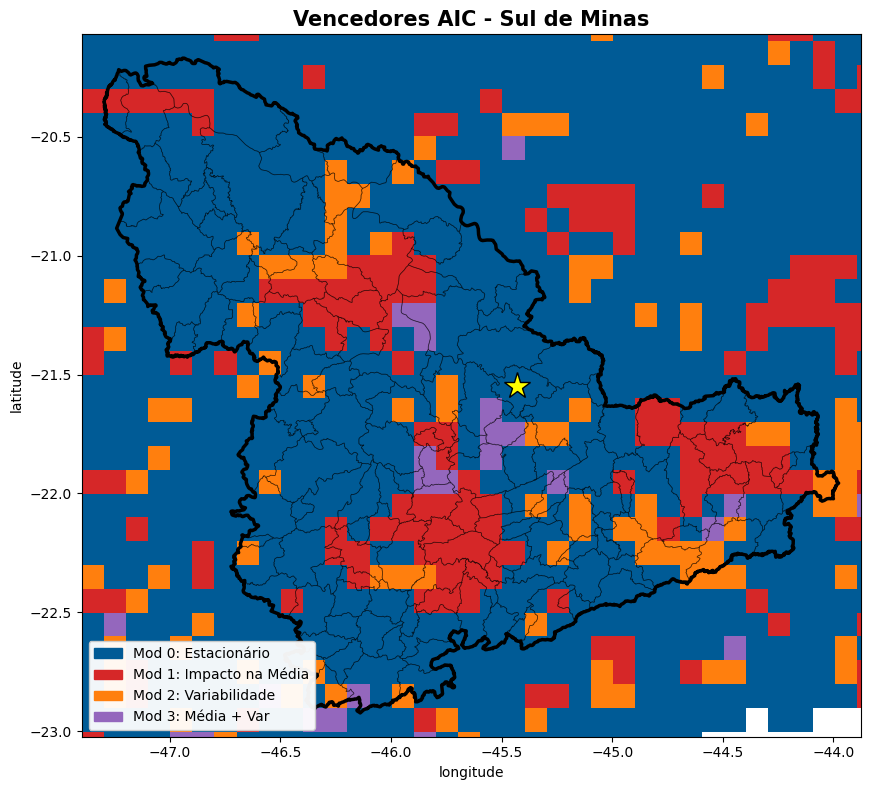


Montando o ranking dos municípios afetados...

✅ RANKING DE MUNICÍPIOS (SUL DE MINAS)


,Município,Modelo,Impacto (mm/ONI)
80,Silvianópolis,1.0,4.8800
63,Minduri,1.0,4.5600
48,Espírito Santo do Dourado,1.0,4.2700
47,Elói Mendes,3.0,4.2600
79,Serranos,1.0,4.1500
85,São Sebastião da Bela Vista,1.0,4.1200
90,Turvolândia,1.0,4.1100
28,Careaçu,1.0,4.1050
36,Claraval,1.0,4.0000
42,Cruzília,1.0,3.9625


In [13]:
# ------------------------------------------------------------------------------
# BLOCO 4: MAPA ESPACIAL E IDENTIFICAÇÃO DOS MUNICÍPIOS (SUL DE MINAS)
# ------------------------------------------------------------------------------
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point

print("Desenhando o mapa focado no Sul de Minas...")

# 1. Coordenadas de Referência (Varginha)
lat_ref, lon_ref = -21.55, -45.43

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

# Define as cores dos modelos
cores_hex = ['#005b96', '#d62728', '#ff7f0e', '#9467bd']
cmap_discreto = ListedColormap(cores_hex)
norma = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_discreto.N)

# Plota os pixels
da_modelos.plot.imshow(ax=ax1, cmap=cmap_discreto, norm=norma, add_colorbar=False, interpolation='none')

# Desenha as fronteiras dos municípios do Sul de MG por cima
muni_mg = geobr.read_municipality(code_muni="MG", year=2020)
muni_sul = gpd.clip(muni_mg, sul_mg)
muni_sul.boundary.plot(ax=ax1, color='black', linewidth=0.5, alpha=0.5)
sul_mg.boundary.plot(ax=ax1, color='black', linewidth=2.5) # Borda grossa da mesorregião

# Estrela em Varginha
ax1.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=20, markeredgecolor='black', label='Varginha')

# Legenda bonitona
nomes_modelos = ['Mod 0: Estacionário', 'Mod 1: Impacto na Média', 'Mod 2: Variabilidade', 'Mod 3: Média + Var']
legend_handles = [mpatches.Patch(color=cores_hex[i], label=nomes_modelos[i]) for i in range(4)]
ax1.legend(handles=legend_handles, loc='lower left', framealpha=0.95)

ax1.set_title("Vencedores AIC - Sul de Minas", fontsize=15, fontweight='bold')
ax1.set_xlim([min_lon - 0.1, max_lon + 0.1])
ax1.set_ylim([min_lat - 0.1, max_lat + 0.1])
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. CRUZAMENTO ESPACIAL (MUNICÍPIOS AFETADOS)
# ------------------------------------------------------------------------------
print("\nMontando o ranking dos municípios afetados...")
pixels_afetados = []
for i in range(len(lats)):
    for j in range(len(lons)):
        mod = matriz_vencedores[i, j]
        if not np.isnan(mod) and mod != 0: # Pega só quem NÃO é o modelo 0
            pixels_afetados.append({'Latitude': lats[i], 'Longitude': lons[j], 'Impacto_mu1': matriz_mu1[i, j], 'Modelo': mod})

if pixels_afetados:
    df_pixels = pd.DataFrame(pixels_afetados)
    pontos = [Point(lon, lat) for lon, lat in zip(df_pixels['Longitude'], df_pixels['Latitude'])]
    gdf_pixels = gpd.GeoDataFrame(df_pixels, geometry=pontos, crs=muni_mg.crs)

    # --- CORREÇÃO DO ÍNDICE DUPLICADO ---
    # Limpa o resíduo do cruzamento anterior para o sjoin funcionar
    if 'index_right' in muni_sul.columns:
        muni_sul = muni_sul.drop(columns=['index_right'])

    # Cruza os pixels com as geometrias dos municípios do Sul de MG
    cidades_afetadas = gpd.sjoin(gdf_pixels, muni_sul, how="inner", predicate="within")

    tabela = cidades_afetadas[['name_muni', 'Modelo', 'Impacto_mu1']].copy()
    tabela.rename(columns={'name_muni': 'Município', 'Impacto_mu1': 'Impacto (mm/ONI)'}, inplace=True)
    tabela['Impacto (mm/ONI)'] = tabela['Impacto (mm/ONI)'].round(2)

    tabela_resumo = tabela.groupby(['Município', 'Modelo']).mean().reset_index()
    tabela_resumo.sort_values(by='Impacto (mm/ONI)', ascending=False, inplace=True)

    print("\n✅ RANKING DE MUNICÍPIOS (SUL DE MINAS)")
    display(tabela_resumo.head(15)) # Mostra os 15 com maior aumento na chuva
else:
    print("Nenhum pixel indicou efeito não-estacionário nessa rodada.")

Limpando os arredores e desenhando apenas dentro do Sul de Minas...


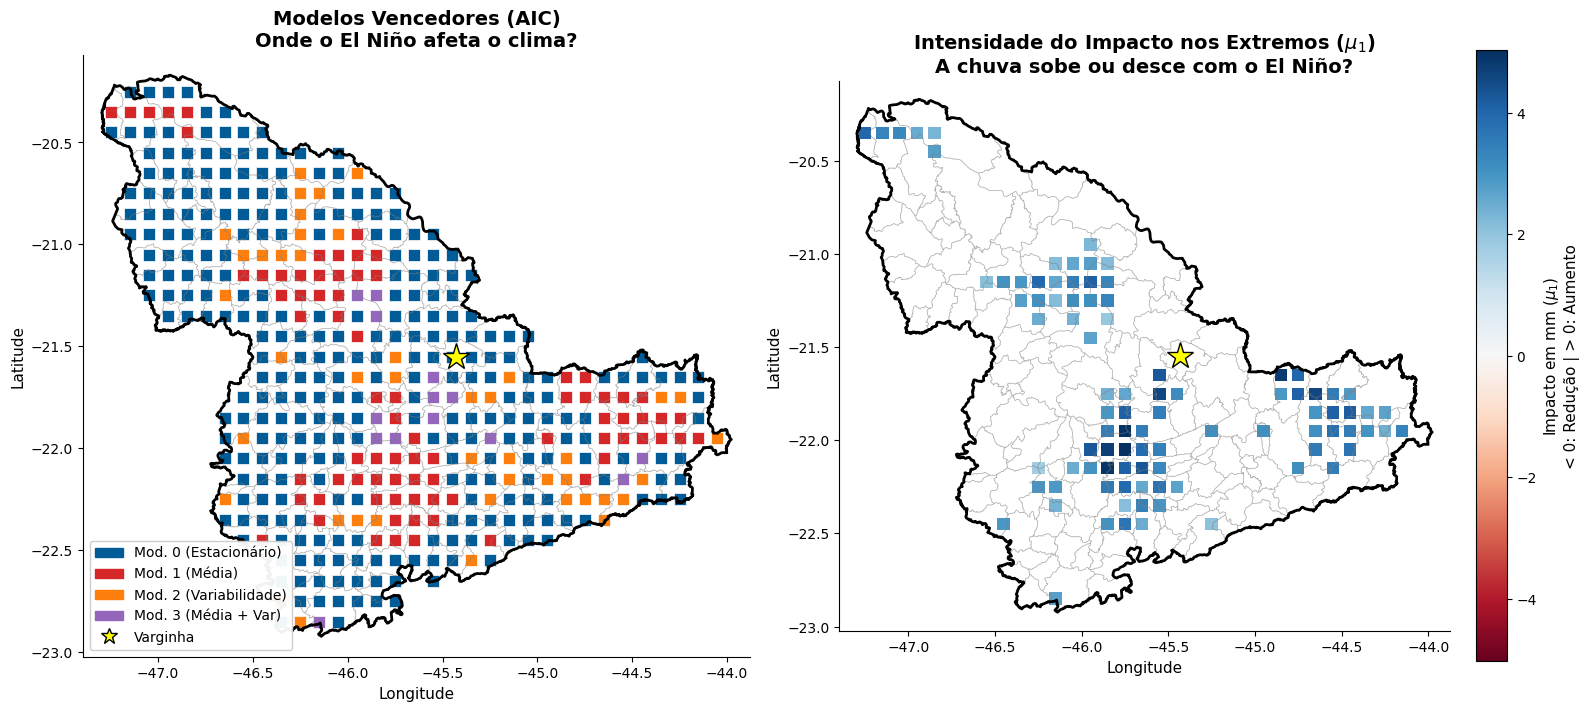

In [15]:
# ==============================================================================
# BLOCO 4: GRÁFICO DUPLO COM SCATTER E RECORTE EXATO NA FRONTEIRA
# ==============================================================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.geometry import Point

print("Limpando os arredores e desenhando apenas dentro do Sul de Minas...")

# 1. Coordenadas de Referência (Varginha)
lat_ref, lon_ref = -21.55, -45.43

# 2. Preparando as camadas geográficas e o polígono de recorte
muni_mg = geobr.read_municipality(code_muni="MG", year=2020)
muni_sul = gpd.clip(muni_mg, sul_mg)
min_lon, min_lat, max_lon, max_lat = sul_mg.total_bounds

# A MÁGICA AQUI: Une todas as geometrias do Sul de MG em um único "molde"
poligono_sul = sul_mg.geometry.unary_union

# 3. Extração das coordenadas APENAS DENTRO DO MOLDE
m0_lons, m0_lats = [], []
m1_lons, m1_lats = [], []
m2_lons, m2_lats = [], []
m3_lons, m3_lats = [], []
mu1_lons, mu1_lats, mu1_vals = [], [], []

for i in range(len(lats)):
    for j in range(len(lons)):
        mod = matriz_vencedores[i, j]
        if not np.isnan(mod):
            # Cria o ponto geométrico do pixel
            ponto_pixel = Point(lons[j], lats[i])

            # Só guarda o dado se o ponto estiver DENTRO do contorno do Sul de MG
            if poligono_sul.contains(ponto_pixel):

                # Filtra os dados para o Mapa 1 (Modelos)
                if mod == 0:
                    m0_lons.append(lons[j]); m0_lats.append(lats[i])
                elif mod == 1:
                    m1_lons.append(lons[j]); m1_lats.append(lats[i])
                elif mod == 2:
                    m2_lons.append(lons[j]); m2_lats.append(lats[i])
                elif mod == 3:
                    m3_lons.append(lons[j]); m3_lats.append(lats[i])

                # Filtra os dados para o Mapa 2 (Impacto mu1)
                if mod in [1, 3]:
                    val_mu1 = matriz_mu1[i, j]
                    if not np.isnan(val_mu1):
                        mu1_lons.append(lons[j])
                        mu1_lats.append(lats[i])
                        mu1_vals.append(val_mu1)

# 4. Desenhando a Figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
tamanho_pixel = 80 # Ajuste o tamanho do quadrado se achar necessário

# ------------------------------------------------------------------------------
# MAPA 1: MODELOS VENCEDORES (ESQUERDA)
# ------------------------------------------------------------------------------
muni_sul.boundary.plot(ax=ax1, color='gray', linewidth=0.5, alpha=0.4)
sul_mg.boundary.plot(ax=ax1, color='black', linewidth=2)

if m0_lons: ax1.scatter(m0_lons, m0_lats, c='#005b96', marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.5)
if m1_lons: ax1.scatter(m1_lons, m1_lats, c='#d62728', marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.5)
if m2_lons: ax1.scatter(m2_lons, m2_lats, c='#ff7f0e', marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.5)
if m3_lons: ax1.scatter(m3_lons, m3_lats, c='#9467bd', marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.5)

ax1.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=20, markeredgecolor='black', zorder=5)

ax1.set_title("Modelos Vencedores (AIC)\nOnde o El Niño afeta o clima?", fontsize=14, fontweight='bold')
ax1.set_xlabel("Longitude", fontsize=11)
ax1.set_ylabel("Latitude", fontsize=11)

# Legenda
nomes_modelos = ['Mod. 0 (Estacionário)', 'Mod. 1 (Média)', 'Mod. 2 (Variabilidade)', 'Mod. 3 (Média + Var)']
cores_hex = ['#005b96', '#d62728', '#ff7f0e', '#9467bd']
legend_handles = [mpatches.Patch(color=cores_hex[i], label=nomes_modelos[i]) for i in range(4)]
legend_handles.append(plt.Line2D([0], [0], marker='*', color='yellow', markersize=12, markeredgecolor='black', linestyle='None', label='Varginha'))
ax1.legend(handles=legend_handles, loc='lower left', framealpha=0.95, fontsize=10)

# ------------------------------------------------------------------------------
# MAPA 2: INTENSIDADE DO IMPACTO (DIREITA)
# ------------------------------------------------------------------------------
muni_sul.boundary.plot(ax=ax2, color='gray', linewidth=0.5, alpha=0.4)
sul_mg.boundary.plot(ax=ax2, color='black', linewidth=2)

if mu1_vals:
    # Trava a escala de cores no zero simetricamente
    limite = max(abs(np.min(mu1_vals)), abs(np.max(mu1_vals)))

    scatter = ax2.scatter(mu1_lons, mu1_lats, c=mu1_vals, cmap='RdBu',
                          marker='s', s=tamanho_pixel, vmin=-limite, vmax=limite,
                          edgecolor='none')

    cbar = plt.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label('Impacto em mm ($\mu_1$)\n< 0: Redução | > 0: Aumento', fontsize=11)

ax2.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=20, markeredgecolor='black', zorder=5)

ax2.set_title("Intensidade do Impacto nos Extremos ($\mu_1$)\nA chuva sobe ou desce com o El Niño?", fontsize=14, fontweight='bold')
ax2.set_xlabel("Longitude", fontsize=11)
ax2.set_ylabel("Latitude", fontsize=11)

# Acabamento das bordas
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim([min_lon - 0.1, max_lon + 0.1])
    ax.set_ylim([min_lat - 0.1, max_lat + 0.1])

plt.tight_layout()
plt.show()

In [16]:
# ==============================================================================
# BLOCO 3: MOTOR GEV DUAL (PROCESSAMENTO PARALELO AIC + BIC)
# ==============================================================================
def ajustar_gev_dual(series_chuva, series_oni):
    validos = ~np.isnan(series_chuva) & ~np.isnan(series_oni)
    y = series_chuva[validos]
    x = series_oni[validos]
    n = len(y)
    if n < 30:
        return [np.nan] * 4 # Retorna NaNs se a série for curta demais

    resultados_aic, resultados_bic = {}, {}
    parametros = {}

    # --------------------------------------------------------------------------
    # M0: ESTACIONÁRIO (3 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m0(p):
        if p[1] <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -p[2], loc=p[0], scale=p[1]))
    res0 = minimize(nll_m0, [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')
    if res0.success:
        resultados_aic[0] = 2 * 3 + 2 * res0.fun
        resultados_bic[0] = 3 * np.log(n) + 2 * res0.fun
        parametros[0] = [res0.x[0], 0, res0.x[1], 0, res0.x[2]]

    # --------------------------------------------------------------------------
    # M1: NÃO-ESTACIONÁRIO NA MÉDIA (4 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m1(p):
        if p[2] <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -p[3], loc=(p[0] + p[1] * x), scale=p[2]))
    res1 = minimize(nll_m1, [res0.x[0], 0, res0.x[1], res0.x[2]] if res0.success else [np.mean(y), 0, np.std(y), 0.1], method='Nelder-Mead')
    if res1.success:
        resultados_aic[1] = 2 * 4 + 2 * res1.fun
        resultados_bic[1] = 4 * np.log(n) + 2 * res1.fun
        parametros[1] = [res1.x[0], res1.x[1], res1.x[2], 0, res1.x[3]]

    # --------------------------------------------------------------------------
    # M2: NÃO-ESTACIONÁRIO NA VARIABILIDADE (4 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m2(p):
        sigma_t = np.exp(p[1] + p[2] * x)
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -p[3], loc=p[0], scale=sigma_t))
    res2 = minimize(nll_m2, [res0.x[0], np.log(res0.x[1]), 0, res0.x[2]] if res0.success else [np.mean(y), np.log(np.std(y)), 0, 0.1], method='Nelder-Mead')
    if res2.success:
        resultados_aic[2] = 2 * 4 + 2 * res2.fun
        resultados_bic[2] = 4 * np.log(n) + 2 * res2.fun
        parametros[2] = [res2.x[0], 0, res2.x[1], res2.x[2], res2.x[3]]

    # --------------------------------------------------------------------------
    # M3: NÃO-ESTACIONÁRIO NA MÉDIA E VARIABILIDADE (5 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m3(p):
        sigma_t = np.exp(p[2] + p[3] * x)
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -p[4], loc=(p[0] + p[1] * x), scale=sigma_t))
    res3 = minimize(nll_m3, [res1.x[0], res1.x[1], np.log(res0.x[1]), 0, res0.x[2]] if res1.success and res0.success else [np.mean(y), 0, np.log(np.std(y)), 0, 0.1], method='Nelder-Mead')
    if res3.success:
        resultados_aic[3] = 2 * 5 + 2 * res3.fun
        resultados_bic[3] = 5 * np.log(n) + 2 * res3.fun
        parametros[3] = [res3.x[0], res3.x[1], res3.x[2], res3.x[3], res3.x[4]]

    # SELEÇÃO INDEPENDENTE DO VENDEDOR
    if not resultados_aic:
        return [np.nan] * 4

    melhor_aic = min(resultados_aic, key=resultados_aic.get)
    melhor_bic = min(resultados_bic, key=resultados_bic.get)

    # Retorna: ID_AIC, mu1_AIC, ID_BIC, mu1_BIC
    return (melhor_aic, parametros[melhor_aic][1], melhor_bic, parametros[melhor_bic][1])

# --- DISPARO DOS MOTORES EM PARALELO ---
chuva_matriz = ds_sul_mg['pr'].values
lats = ds_sul_mg.latitude.values
lons = ds_sul_mg.longitude.values
anos_clima = ds_sul_mg.ano.values

df_enso_alinhado = df_covariavel_enso[df_covariavel_enso['ano'].isin(anos_clima)].sort_values('ano')
vetor_oni = df_enso_alinhado['ONI_Verao'].values

tarefas = [(i, j, chuva_matriz[:, i, j]) for i in range(len(lats)) for j in range(len(lons)) if not np.isnan(chuva_matriz[:, i, j]).all()]

print(f"Rodando a competição AIC vs BIC para {len(tarefas)} pixels no Sul de MG...")
resultados = Parallel(n_jobs=-1)(delayed(ajustar_gev_dual)(serie, vetor_oni) for _, _, serie in tqdm(tarefas))

# Remontando os grids espaciais
matriz_vencedores_aic = np.full((len(lats), len(lons)), np.nan)
matriz_mu1_aic = np.full((len(lats), len(lons)), np.nan)
matriz_vencedores_bic = np.full((len(lats), len(lons)), np.nan)
matriz_mu1_bic = np.full((len(lats), len(lons)), np.nan)

for idx, (i, j, _) in enumerate(tarefas):
    id_aic, mu1_aic, id_bic, mu1_bic = resultados[idx]
    matriz_vencedores_aic[i, j] = id_aic
    matriz_mu1_aic[i, j] = mu1_aic
    matriz_vencedores_bic[i, j] = id_bic
    matriz_mu1_bic[i, j] = mu1_bic

print("✅ Modelagem estatística dual finalizada com sucesso!")

Rodando a competição AIC vs BIC para 1135 pixels no Sul de MG...


  0%|          | 0/1135 [00:00<?, ?it/s]

✅ Modelagem estatística dual finalizada com sucesso!


Cortando os mapas sob medida e gerando a comparação...


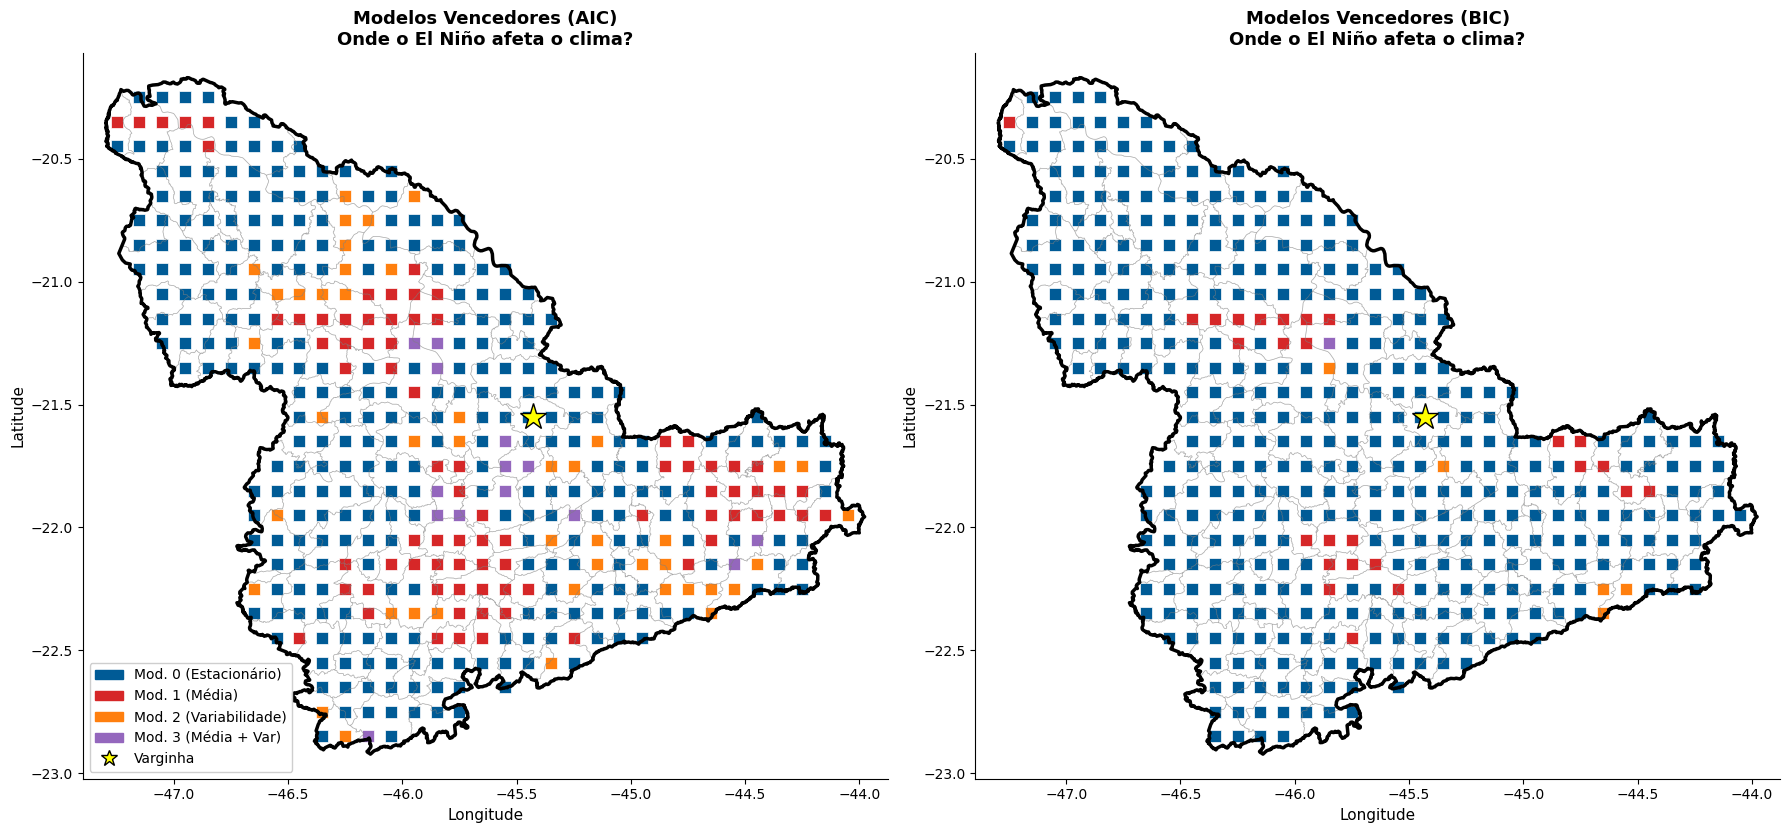

In [17]:
# ==============================================================================
# BLOCO 4: GRÁFICO COMPARATIVO COMPLETO (MODELOS AIC VS MODELOS BIC)
# ==============================================================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.geometry import Point

print("Cortando os mapas sob medida e gerando a comparação...")

# 1. Coordenadas de Referência (Varginha)
lat_ref, lon_ref = -21.55, -45.43

# 2. Preparação e Corte a Laser dos Municípios (Apenas os de dentro do Sul de MG)
muni_mg = geobr.read_municipality(code_muni="MG", year=2020)
muni_sul_recortado = gpd.clip(muni_mg, sul_mg)
min_lon, min_lat, max_lon, max_lat = sul_mg.total_bounds
poligono_sul = sul_mg.geometry.unary_union

# 3. Listas para armazenar os pontos válidos de cada critério
aic_coords = {0: ([], []), 1: ([], []), 2: ([], []), 3: ([])}
bic_coords = {0: ([], []), 1: ([], []), 2: ([], []), 3: ([])}

# Inicializando dicionários de coordenadas para o scatter plot
for m in [0, 1, 2, 3]:
    aic_coords[m] = ([], [])
    bic_coords[m] = ([], [])

for i in range(len(lats)):
    for j in range(len(lons)):
        ponto_pixel = Point(lons[j], lats[i])

        # Filtro geométrico: só processa se estiver DENTRO do Sul de MG
        if poligono_sul.contains(ponto_pixel):
            mod_aic = matriz_vencedores_aic[i, j]
            mod_bic = matriz_vencedores_bic[i, j]

            if not np.isnan(mod_aic):
                aic_coords[int(mod_aic)][0].append(lons[j])
                aic_coords[int(mod_aic)][1].append(lats[i])

            if not np.isnan(mod_bic):
                bic_coords[int(mod_bic)][0].append(lons[j])
                bic_coords[int(mod_bic)][1].append(lats[i])

# 4. Configuração da Tela Lado a Lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
tamanho_pixel = 80
cores_hex = ['#005b96', '#d62728', '#ff7f0e', '#9467bd']

# ------------------------------------------------------------------------------
# SUBPLOT 1: MODELOS VENCEDORES VIA AIC
# ------------------------------------------------------------------------------
muni_sul_recortado.boundary.plot(ax=ax1, color='gray', linewidth=0.5, alpha=0.4)
sul_mg.boundary.plot(ax=ax1, color='black', linewidth=2.5)

for m, cor in enumerate(cores_hex):
    lons_plot, lats_plot = aic_coords[m]
    if lons_plot:
        ax1.scatter(lons_plot, lats_plot, c=cor, marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.5)

ax1.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=20, markeredgecolor='black', zorder=5)
ax1.set_title("Modelos Vencedores (AIC)\nOnde o El Niño afeta o clima?", fontsize=13, fontweight='bold')

# ------------------------------------------------------------------------------
# SUBPLOT 2: MODELOS VENCEDORES VIA BIC
# ------------------------------------------------------------------------------
muni_sul_recortado.boundary.plot(ax=ax2, color='gray', linewidth=0.5, alpha=0.4)
sul_mg.boundary.plot(ax=ax2, color='black', linewidth=2.5)

for m, cor in enumerate(cores_hex):
    lons_plot, lats_plot = bic_coords[m]
    if lons_plot:
        ax2.scatter(lons_plot, lats_plot, c=cor, marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.5)

ax2.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=20, markeredgecolor='black', zorder=5)
ax2.set_title("Modelos Vencedores (BIC)\nOnde o El Niño afeta o clima?", fontsize=13, fontweight='bold')

# ------------------------------------------------------------------------------
# ACABAMENTO ESTÉTICO GERAL
# ------------------------------------------------------------------------------
nomes_modelos = ['Mod. 0 (Estacionário)', 'Mod. 1 (Média)', 'Mod. 2 (Variabilidade)', 'Mod. 3 (Média + Var)']
legend_handles = [mpatches.Patch(color=cores_hex[i], label=nomes_modelos[i]) for i in range(4)]
legend_handles.append(plt.Line2D([0], [0], marker='*', color='yellow', markersize=12, markeredgecolor='black', linestyle='None', label='Varginha'))

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim([min_lon - 0.1, max_lon + 0.1])
    ax.set_ylim([min_lat - 0.1, max_lat + 0.1])
    ax.set_xlabel("Longitude", fontsize=11)
    ax.set_ylabel("Latitude", fontsize=11)

# Posiciona a legenda centralizada na parte inferior para os dois mapas aproveitarem
ax1.legend(handles=legend_handles, loc='lower left', framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
# ==============================================================================
# EXTRAÇÃO DO RANKING DE MUNICÍPIOS - CRITÉRIO BIC (ZONAS DE CERTEZA ABSOLUTA)
# ==============================================================================
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

print("Filtrando os pixels sobreviventes e cruzando com o mapa das cidades...")

pixels_bic = []
for i in range(len(lats)):
    for j in range(len(lons)):
        mod = matriz_vencedores_bic[i, j]

        # Pega apenas onde o BIC rejeitou o Modelo Estacionário (Mod 1, 2 ou 3)
        if not np.isnan(mod) and mod != 0:
            pixels_bic.append({
                'Latitude': lats[i],
                'Longitude': lons[j],
                'Impacto_mu1': matriz_mu1_bic[i, j],
                'Modelo': int(mod)
            })

if pixels_bic:
    df_pixels_bic = pd.DataFrame(pixels_bic)
    pontos_bic = [Point(lon, lat) for lon, lat in zip(df_pixels_bic['Longitude'], df_pixels_bic['Latitude'])]
    gdf_pixels_bic = gpd.GeoDataFrame(df_pixels_bic, geometry=pontos_bic, crs=muni_mg.crs)

    # Cruza com os municípios cortados do Sul de Minas
    cidades_bic = gpd.sjoin(gdf_pixels_bic, muni_sul_recortado, how="inner", predicate="within")

    # Estrutura a tabela final
    tabela_bic = cidades_bic[['name_muni', 'Modelo', 'Impacto_mu1']].copy()
    tabela_bic.rename(columns={'name_muni': 'Município', 'Impacto_mu1': 'Impacto (mm/ONI)'}, inplace=True)
    tabela_bic['Impacto (mm/ONI)'] = tabela_bic['Impacto (mm/ONI)'].round(2)

    # Mapeia os IDs para os nomes textuais dos modelos para a tabela ficar impecável
    mapa_nomes = {1: 'Mod 1 (Média)', 2: 'Mod 2 (Variabilidade)', 3: 'Mod 3 (Média + Var)'}
    tabela_bic['Modelo'] = tabela_bic['Modelo'].map(mapa_nomes)

    # Agrupa por município tirando a média caso a cidade tenha mais de um pixel resistente
    tabela_resumo_bic = tabela_bic.groupby(['Município', 'Modelo']).mean().reset_index()
    tabela_resumo_bic.sort_values(by='Impacto (mm/ONI)', ascending=False, inplace=True)

    print("\n✅ RANKING BIC: MUNICÍPIOS COM IMPACTO INQUESTIONÁVEL NO SUL DE MINAS")
    display(tabela_resumo_bic)
else:
    print("\n⚠️ Uai, nenhum pixel não-estacionário sobreviveu ao rigor do BIC no Sul de Minas!")

Filtrando os pixels sobreviventes e cruzando com o mapa das cidades...

✅ RANKING BIC: MUNICÍPIOS COM IMPACTO INQUESTIONÁVEL NO SUL DE MINAS


,Município,Modelo,Impacto (mm/ONI)
20,Silvianópolis,Mod 1 (Média),4.880
15,Minduri,Mod 1 (Média),4.560
7,Careaçu,Mod 1 (Média),4.310
12,Cruzília,Mod 1 (Média),4.300
13,Espírito Santo do Dourado,Mod 1 (Média),4.270
18,Pouso Alegre,Mod 1 (Média),4.265
19,Serranos,Mod 1 (Média),4.150
21,São Sebastião da Bela Vista,Mod 1 (Média),4.120
9,Claraval,Mod 1 (Média),4.000
0,Alfenas,Mod 1 (Média),3.940


In [19]:
# ==============================================================================
# BLOCO 3: MOTOR GEV TRIO (PROCESSAMENTO PARALELO AIC + AICc + BIC)
# ==============================================================================
def ajustar_gev_trio(series_chuva, series_oni):
    validos = ~np.isnan(series_chuva) & ~np.isnan(series_oni)
    y = series_chuva[validos]
    x = series_oni[validos]
    n = len(y)
    if n < 30:
        return [np.nan] * 6 # Retorna NaNs se a série for curta demais

    resultados_aic = {}
    resultados_aicc = {}
    resultados_bic = {}
    parametros = {}

    # --------------------------------------------------------------------------
    # M0: ESTACIONÁRIO (3 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m0(p):
        if p[1] <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -p[2], loc=p[0], scale=p[1]))
    res0 = minimize(nll_m0, [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')
    if res0.success:
        aic_m0 = 2 * 3 + 2 * res0.fun
        resultados_aic[0] = aic_m0
        resultados_aicc[0] = aic_m0 + (2 * 3 * 4) / (n - 3 - 1)
        resultados_bic[0] = 3 * np.log(n) + 2 * res0.fun
        parametros[0] = [res0.x[0], 0, res0.x[1], 0, res0.x[2]]

    # --------------------------------------------------------------------------
    # M1: NÃO-ESTACIONÁRIO NA MÉDIA (4 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m1(p):
        if p[2] <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -p[3], loc=(p[0] + p[1] * x), scale=p[2]))
    res1 = minimize(nll_m1, [res0.x[0], 0, res0.x[1], res0.x[2]] if res0.success else [np.mean(y), 0, np.std(y), 0.1], method='Nelder-Mead')
    if res1.success:
        aic_m1 = 2 * 4 + 2 * res1.fun
        resultados_aic[1] = aic_m1
        resultados_aicc[1] = aic_m1 + (2 * 4 * 5) / (n - 4 - 1)
        resultados_bic[1] = 4 * np.log(n) + 2 * res1.fun
        parametros[1] = [res1.x[0], res1.x[1], res1.x[2], 0, res1.x[3]]

    # --------------------------------------------------------------------------
    # M2: NÃO-ESTACIONÁRIO NA VARIABILIDADE (4 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m2(p):
        sigma_t = np.exp(p[1] + p[2] * x)
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -p[3], loc=p[0], scale=sigma_t))
    res2 = minimize(nll_m2, [res0.x[0], np.log(res0.x[1]), 0, res0.x[2]] if res0.success else [np.mean(y), np.log(np.std(y)), 0, 0.1], method='Nelder-Mead')
    if res2.success:
        aic_m2 = 2 * 4 + 2 * res2.fun
        resultados_aic[2] = aic_m2
        resultados_aicc[2] = aic_m2 + (2 * 4 * 5) / (n - 4 - 1)
        resultados_bic[2] = 4 * np.log(n) + 2 * res2.fun
        parametros[2] = [res2.x[0], 0, res2.x[1], res2.x[2], res2.x[3]]

    # --------------------------------------------------------------------------
    # M3: NÃO-ESTACIONÁRIO NA MÉDIA E VARIABILIDADE (5 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m3(p):
        sigma_t = np.exp(p[2] + p[3] * x)
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -p[4], loc=(p[0] + p[1] * x), scale=sigma_t))
    res3 = minimize(nll_m3, [res1.x[0], res1.x[1], np.log(res0.x[1]), 0, res0.x[2]] if res1.success and res0.success else [np.mean(y), 0, np.log(np.std(y)), 0, 0.1], method='Nelder-Mead')
    if res3.success:
        aic_m3 = 2 * 5 + 2 * res3.fun
        resultados_aic[3] = aic_m3
        resultados_aicc[3] = aic_m3 + (2 * 5 * 6) / (n - 5 - 1)
        resultados_bic[3] = 5 * np.log(n) + 2 * res3.fun
        parametros[3] = [res3.x[0], res3.x[1], res3.x[2], res3.x[3], res3.x[4]]

    # SELEÇÃO INDEPENDENTE DOS TRÊS VENCEDORES
    if not resultados_aic:
        return [np.nan] * 6

    melhor_aic = min(resultados_aic, key=resultados_aic.get)
    melhor_aicc = min(resultados_aicc, key=resultados_aicc.get)
    melhor_bic = min(resultados_bic, key=resultados_bic.get)

    return (melhor_aic, parametros[melhor_aic][1],
            melhor_aicc, parametros[melhor_aicc][1],
            melhor_bic, parametros[melhor_bic][1])

# --- DISPARO DOS MOTORES EM PARALELO ---
chuva_matriz = ds_sul_mg['pr'].values
lats = ds_sul_mg.latitude.values
lons = ds_sul_mg.longitude.values
anos_clima = ds_sul_mg.ano.values

df_enso_alinhado = df_covariavel_enso[df_covariavel_enso['ano'].isin(anos_clima)].sort_values('ano')
vetor_oni = df_enso_alinhado['ONI_Verao'].values

tarefas = [(i, j, chuva_matriz[:, i, j]) for i in range(len(lats)) for j in range(len(lons)) if not np.isnan(chuva_matriz[:, i, j]).all()]

print(f"Rodando a competição AIC vs AICc vs BIC para {len(tarefas)} pixels no Sul de MG...")
resultados = Parallel(n_jobs=-1)(delayed(ajustar_gev_trio)(serie, vetor_oni) for _, _, serie in tarefas)

# Remontando os grids espaciais independentes
matriz_vencedores_aic = np.full((len(lats), len(lons)), np.nan)
matriz_mu1_aic = np.full((len(lats), len(lons)), np.nan)
matriz_vencedores_aicc = np.full((len(lats), len(lons)), np.nan)
matriz_mu1_aicc = np.full((len(lats), len(lons)), np.nan)
matriz_vencedores_bic = np.full((len(lats), len(lons)), np.nan)
matriz_mu1_bic = np.full((len(lats), len(lons)), np.nan)

for idx, (i, j, _) in enumerate(tarefas):
    id_aic, mu1_aic, id_aicc, mu1_aicc, id_bic, mu1_bic = resultados[idx]
    matriz_vencedores_aic[i, j] = id_aic
    matriz_mu1_aic[i, j] = mu1_aic
    matriz_vencedores_aicc[i, j] = id_aicc
    matriz_mu1_aicc[i, j] = mu1_aicc
    matriz_vencedores_bic[i, j] = id_bic
    matriz_mu1_bic[i, j] = mu1_bic

print("✅ Modelagem estatística tripla finalizada com sucesso!")

Rodando a competição AIC vs AICc vs BIC para 1135 pixels no Sul de MG...
✅ Modelagem estatística tripla finalizada com sucesso!


Cortando os mapas sob medida e gerando o painel de 3 eixos...


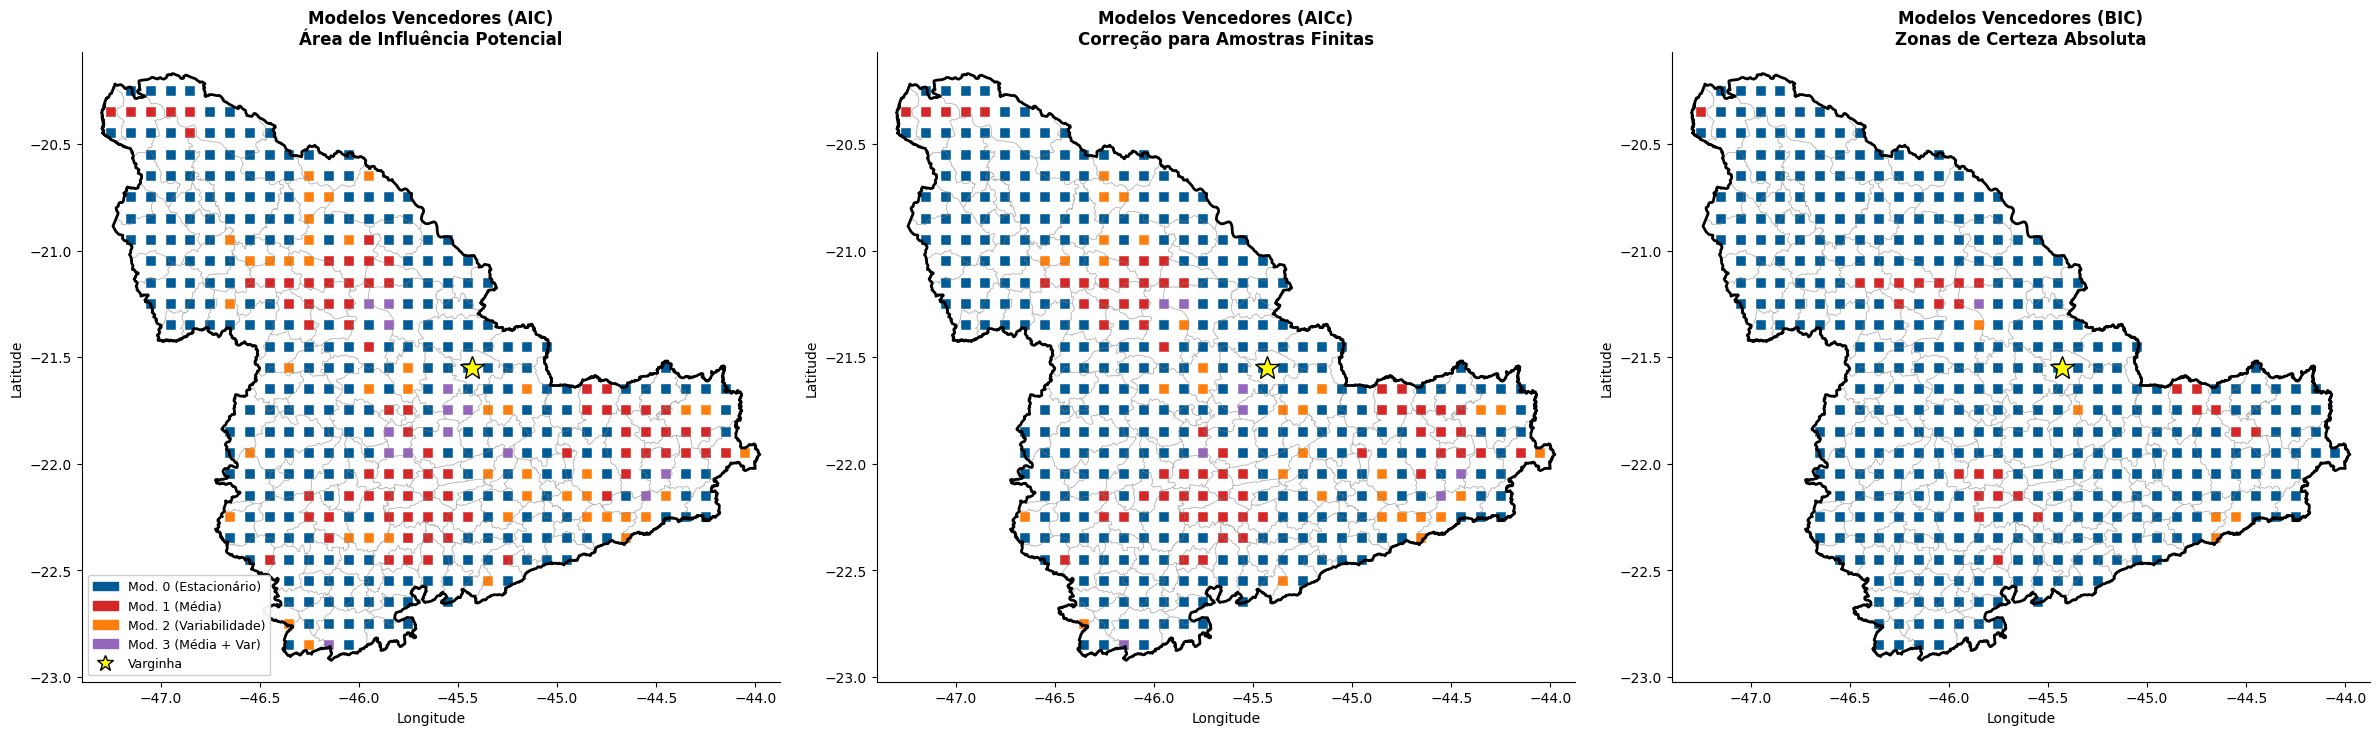

In [20]:
# ==============================================================================
# BLOCO 4: GRÁFICO COMPARATIVO TRIPLO (MODELOS AIC VS AICc VS BIC)
# ==============================================================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.geometry import Point

print("Cortando os mapas sob medida e gerando o painel de 3 eixos...")

# 1. Coordenadas de Referência (Varginha)
lat_ref, lon_ref = -21.55, -45.43

# 2. Corte a Laser dos Municípios
muni_mg = geobr.read_municipality(code_muni="MG", year=2020)
muni_sul_recortado = gpd.clip(muni_mg, sul_mg)
min_lon, min_lat, max_lon, max_lat = sul_mg.total_bounds
poligono_sul = sul_mg.geometry.unary_union

# 3. Inicializando estruturas para guardar coordenadas por modelo
aic_coords = {0: ([], []), 1: ([], []), 2: ([], []), 3: ([], [])}
aicc_coords = {0: ([], []), 1: ([], []), 2: ([], []), 3: ([], [])}
bic_coords = {0: ([], []), 1: ([], []), 2: ([], []), 3: ([], [])}

for i in range(len(lats)):
    for j in range(len(lons)):
        ponto_pixel = Point(lons[j], lats[i])

        # Filtro geométrico estrito
        if poligono_sul.contains(ponto_pixel):
            mod_aic = matriz_vencedores_aic[i, j]
            mod_aicc = matriz_vencedores_aicc[i, j]
            if not np.isnan(mod_aicc):
                aicc_coords[int(mod_aicc)][0].append(lons[j])
                aicc_coords[int(mod_aicc)][1].append(lats[i])
            mod_bic = matriz_vencedores_bic[i, j]

            if not np.isnan(mod_aic):
                aic_coords[int(mod_aic)][0].append(lons[j])
                aic_coords[int(mod_aic)][1].append(lats[i])
            if not np.isnan(mod_bic):
                bic_coords[int(mod_bic)][0].append(lons[j])
                bic_coords[int(mod_bic)][1].append(lats[i])

# 4. Configuração da Tela com 3 Subplots Lado a Lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
tamanho_pixel = 60 # Ajustado para acomodar 3 telas sem espremer
cores_hex = ['#005b96', '#d62728', '#ff7f0e', '#9467bd']

# --- MAPA 1: AIC ---
muni_sul_recortado.boundary.plot(ax=ax1, color='gray', linewidth=0.5, alpha=0.4)
sul_mg.boundary.plot(ax=ax1, color='black', linewidth=2)
for m, cor in enumerate(cores_hex):
    lo, la = aic_coords[m]
    if lo: ax1.scatter(lo, la, c=cor, marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.3)
ax1.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=18, markeredgecolor='black', zorder=5)
ax1.set_title("Modelos Vencedores (AIC)\nÁrea de Influência Potencial", fontsize=12, fontweight='bold')

# --- MAPA 2: AICc ---
muni_sul_recortado.boundary.plot(ax=ax2, color='gray', linewidth=0.5, alpha=0.4)
sul_mg.boundary.plot(ax=ax2, color='black', linewidth=2)
for m, cor in enumerate(cores_hex):
    lo, la = aicc_coords[m]
    if lo: ax2.scatter(lo, la, c=cor, marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.3)
ax2.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=18, markeredgecolor='black', zorder=5)
ax2.set_title("Modelos Vencedores (AICc)\nCorreção para Amostras Finitas", fontsize=12, fontweight='bold')

# --- MAPA 3: BIC ---
muni_sul_recortado.boundary.plot(ax=ax3, color='gray', linewidth=0.5, alpha=0.4)
sul_mg.boundary.plot(ax=ax3, color='black', linewidth=2)
for m, cor in enumerate(cores_hex):
    lo, la = bic_coords[m]
    if lo: ax3.scatter(lo, la, c=cor, marker='s', s=tamanho_pixel, edgecolor='white', linewidth=0.3)
ax3.plot(lon_ref, lat_ref, marker='*', color='yellow', markersize=18, markeredgecolor='black', zorder=5)
ax3.set_title("Modelos Vencedores (BIC)\nZonas de Certeza Absoluta", fontsize=12, fontweight='bold')

# --- CONFIGURAÇÕES COMUNS ---
nomes_modelos = ['Mod. 0 (Estacionário)', 'Mod. 1 (Média)', 'Mod. 2 (Variabilidade)', 'Mod. 3 (Média + Var)']
legend_handles = [mpatches.Patch(color=cores_hex[i], label=nomes_modelos[i]) for i in range(4)]
legend_handles.append(plt.Line2D([0], [0], marker='*', color='yellow', markersize=12, markeredgecolor='black', linestyle='None', label='Varginha'))

for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim([min_lon - 0.1, max_lon + 0.1])
    ax.set_ylim([min_lat - 0.1, max_lat + 0.1])
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)

ax1.legend(handles=legend_handles, loc='lower left', framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.show()